In [1]:
# load data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb



In [2]:
ab = pd.read_csv(r'marketing_AB.csv')

In [3]:
# over view
ab.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
ab.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='str')

In [5]:
ab.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 32.6 MB


In [6]:
# check for null
ab.isna().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [7]:
# check test group
ab['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [9]:
ab['converted'].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [24]:
# check which group has most purchase

# count total size of each group
group_total= ab['test group'].value_counts()

# count true converted in each group
group_conv= ab[ab['converted']==True]['test group'].value_counts()
#calculate the conversion / sale rate on each grp
conv_rate = (group_conv/ group_total) *100
conv_rate

test group
ad     2.554656
psa    1.785411
Name: count, dtype: float64

(array([0, 1]), [Text(0, 0, 'ad'), Text(1, 0, 'psa')])

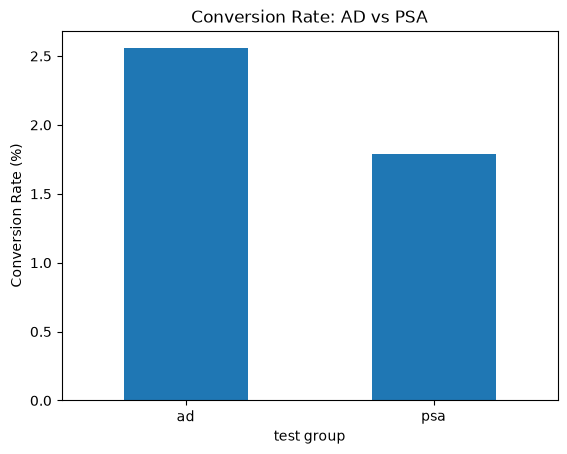

In [27]:
# graph
conv_rate.plot(kind='bar')
plt.title('Conversion Rate: AD vs PSA')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)

A/B Testing Analysis — Ad vs PSA Conversion Rate
This analysis compares the conversion rate between users who saw an advertisement ("ad" group) versus users who saw only a public service announcement ("psa" group — the control).
The ad group achieved a conversion rate of approximately 2.55%
The psa group achieved a conversion rate of approximately 1.79%
While the psa group's performance was not negligible, the ad group still outperformed it by a noticeable margin
Conclusion: Showing the advertisement had a measurable positive impact on conversions compared to the control group. This suggests the ad campaign was effective in driving purchases, justifying continued investment in advertising over relying on organic/PSA exposure alone.
(Note: Raw conversion counts were higher for the ad group primarily due to its much larger sample size — the rate comparison above gives a fairer, apples-to-apples view of performance.)

In [4]:
ab['total ads'].head()

0    130
1     93
2     21
3    355
4    276
Name: total ads, dtype: int64

In [ ]:
# check the affect on converted by total ads
ab.groupby('converted')['total ads'].mean()
# 

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64